In [18]:
## Import libraries
from pathlib import Path
from rasterio.plot import show as display_raster

# from opencropphenotyping.io import find_band
from opencropphenotyping.indices import compute_ndvi, compute_ndre
from opencropphenotyping.io import read_band, write_png, write_raster, resample_raster

In [5]:
## Find paths to the bands of interest

project_root = Path.cwd().parent
output_dir_processed = project_root / "data" / "processed"
output_dir_images = project_root / "docs" / "images"

# safe_dir = (project_root / "data" / "raw" / "sentinel_2" / "S2A_MSIL2A_20250804T104701_N0511_R051_T31TCJ_20250804T161517.SAFE")

# b04_path = find_band(safe_dir, "B04")
# b08_path = find_band(safe_dir, "B08")

# Use the toy dataset for testing
toy_dir = project_root / "data" / "toy_dataset"

b04_path = toy_dir / "toy_image_b04.tif"
b08_path = toy_dir / "toy_image_b08.tif"

print(b04_path.name)
print(b08_path.name)

toy_image_b04.tif
toy_image_b08.tif


In [9]:
## Read the bands

red, red_profile = read_band(b04_path)
nir, _ = read_band(b08_path)

print(red.shape)
print(red.dtype)

print(nir.shape)
print(nir.dtype)

print(red_profile)

(512, 512)
uint16
(512, 512)
uint16
{'driver': 'JP2OpenJPEG', 'dtype': 'uint16', 'nodata': None, 'width': 512, 'height': 512, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 340000.0,
       0.0, -10.0, 4840020.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': False}


In [10]:
# Compute NDVI and write the results

ndvi = compute_ndvi(red, nir)
write_raster(ndvi, red_profile, output_dir_processed / "ndvi.tif")
write_png(ndvi, output_dir_images / "ndvi.png")

In [11]:
# Add to documentation

write_png(red, output_dir_images / "red.png")
write_png(nir, output_dir_images / "nir.png")
write_png(ndvi, output_dir_images / "ndvi.png")

In [21]:
# Prepare for NDRE computation
b05_path = toy_dir / "toy_image_b05.tif" #red_edge 20m

red_edge_20m, red_edge_20m_profile = read_band(b05_path)

print(nir.shape)
print(red_edge_20m.shape)


(512, 512)
(256, 256)


In [22]:
# Resample the bands to a lower resolution and compute NDVI again
red_edge_10m, red_edge_10m_profile = resample_raster(
    image = red_edge_20m, 
    profile = red_edge_20m_profile, 
    target_profile = red_profile
    )

print(red_edge_10m.shape)

(512, 512)


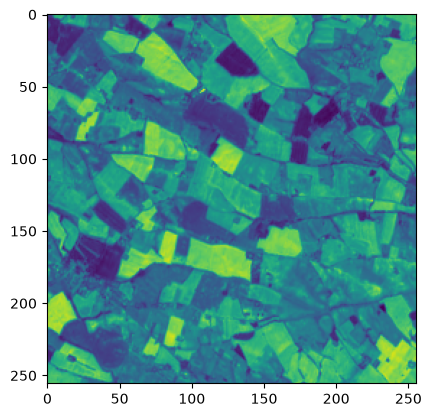

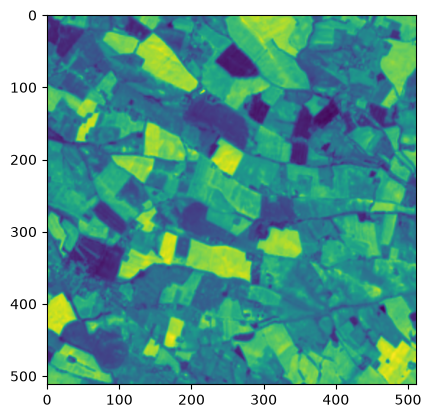

<Axes: >

In [23]:
# Visual check of the resampled red edge band
write_png(red_edge_20m, output_dir_images / "red_edge_20m.png")
display_raster(red_edge_20m)
write_png(red_edge_10m, output_dir_images / "red_edge_10m.png")
display_raster(red_edge_10m)

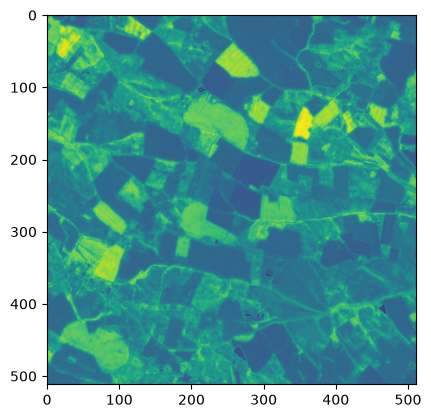

In [25]:
# Compute NDRE and write the results
ndre = compute_ndre(nir, red_edge_10m)
display_raster(ndre)
write_raster(ndre, red_edge_10m_profile, output_dir_processed / "ndre.tif")
write_png(ndre, output_dir_images / "ndre.png")